In [2]:
import numpy as np
import pandas as pd

In [3]:
Y_df = pd.read_csv('https://raw.githubusercontent.com/Nixtla/transfer-learning-time-series/main/datasets/tourism.csv')
Y_df = Y_df.rename({'Trips': 'y', 'Quarter': 'ds'}, axis=1)
Y_df.insert(0, 'Country', 'Australia')
Y_df = Y_df[['Country', 'Region', 'State', 'Purpose', 'ds', 'y']]
Y_df['ds'] = Y_df['ds'].str.replace(r'(\d+) (Q\d)', r'\1-\2', regex=True)
Y_df['ds'] = pd.PeriodIndex(Y_df["ds"], freq='Q').to_timestamp()
Y_df

,Country,Region,State,Purpose,ds,y
0,Australia,Adelaide,South Australia,Business,1998-01-01,135.077690
1,Australia,Adelaide,South Australia,Business,1998-04-01,109.987316
2,Australia,Adelaide,South Australia,Business,1998-07-01,166.034687
3,Australia,Adelaide,South Australia,Business,1998-10-01,127.160464
4,Australia,Adelaide,South Australia,Business,1999-01-01,137.448533
...,...,...,...,...,...,...
24315,Australia,Yorke Peninsula,South Australia,Visiting,2016-10-01,33.672151
24316,Australia,Yorke Peninsula,South Australia,Visiting,2017-01-01,46.223014
24317,Australia,Yorke Peninsula,South Australia,Visiting,2017-04-01,50.582837
24318,Australia,Yorke Peninsula,South Australia,Visiting,2017-07-01,27.766728


In [4]:
Y_df["unique_id"] = Y_df["Country"] + "/" + Y_df["State"] + "/" + Y_df["Region"] + "/" + Y_df["Purpose"]

In [5]:
horizon = 8
Y_test_df = Y_df.groupby("unique_id", as_index=False).tail(horizon)
Y_train_df = Y_df.drop(Y_test_df.index)

In [6]:
from hierarchicalforecast.utils import aggregate_temporal

spec_temporal = {"year": 4, "semiannual": 2, "quarter": 1}

In [7]:
Y_train_df, S_train_df, tags_train = aggregate_temporal(df=Y_train_df, spec=spec_temporal)
Y_test_df, S_test_df, tags_test = aggregate_temporal(df=Y_test_df,  spec=spec_temporal)

In [8]:
Y_train_df[Y_train_df['unique_id'] == 'Australia/ACT/Canberra/Business']
# S_train_df.iloc[:5, :5]

,temporal_id,unique_id,ds,y
0,year-1,Australia/ACT/Canberra/Business,1998-10-01,481.394885
1,year-2,Australia/ACT/Canberra/Business,1999-10-01,592.395157
2,year-3,Australia/ACT/Canberra/Business,2000-10-01,613.692622
3,year-4,Australia/ACT/Canberra/Business,2001-10-01,519.632984
4,year-5,Australia/ACT/Canberra/Business,2002-10-01,625.864384
...,...,...,...,...
16483,quarter-68,Australia/ACT/Canberra/Business,2014-10-01,154.034213
16484,quarter-69,Australia/ACT/Canberra/Business,2015-01-01,101.372970
16485,quarter-70,Australia/ACT/Canberra/Business,2015-04-01,155.481251
16486,quarter-71,Australia/ACT/Canberra/Business,2015-07-01,244.350054


In [9]:
from hierarchicalforecast.utils import make_future_dataframe

Y_test_df_new = make_future_dataframe(Y_train_df, freq="QS", h=horizon)
Y_test_df_new[Y_test_df_new['unique_id'] == 'Australia/ACT/Canberra/Business']

,unique_id,ds
0,Australia/ACT/Canberra/Business,2016-01-01
1,Australia/ACT/Canberra/Business,2016-04-01
2,Australia/ACT/Canberra/Business,2016-07-01
3,Australia/ACT/Canberra/Business,2016-10-01
4,Australia/ACT/Canberra/Business,2017-01-01
5,Australia/ACT/Canberra/Business,2017-04-01
6,Australia/ACT/Canberra/Business,2017-07-01
7,Australia/ACT/Canberra/Business,2017-10-01


In [10]:
Y_test_df_new, S_test_df_new, tags_test_new = aggregate_temporal(df=Y_test_df_new,  spec=spec_temporal)

In [11]:
Y_test_df_new[Y_test_df_new['unique_id'] == 'Australia/ACT/Canberra/Business']

,temporal_id,unique_id,ds
0,year-1,Australia/ACT/Canberra/Business,2016-10-01
1,year-2,Australia/ACT/Canberra/Business,2017-10-01
608,semiannual-1,Australia/ACT/Canberra/Business,2016-04-01
609,semiannual-2,Australia/ACT/Canberra/Business,2016-10-01
610,semiannual-3,Australia/ACT/Canberra/Business,2017-04-01
611,semiannual-4,Australia/ACT/Canberra/Business,2017-10-01
1824,quarter-1,Australia/ACT/Canberra/Business,2016-01-01
1825,quarter-2,Australia/ACT/Canberra/Business,2016-04-01
1826,quarter-3,Australia/ACT/Canberra/Business,2016-07-01
1827,quarter-4,Australia/ACT/Canberra/Business,2016-10-01


In [12]:
from statsforecast.models import AutoETS
from statsforecast.core import StatsForecast

Y_hat_dfs = []
id_cols = ["unique_id", "temporal_id", "ds", "y"]
# We will train a model for each temporal level
for level, temporal_ids_train in tags_train.items():
    # Filter the data for the level
    Y_level_train = Y_train_df.query("temporal_id in @temporal_ids_train")
    temporal_ids_test = tags_test[level]
    Y_level_test = Y_test_df.query("temporal_id in @temporal_ids_test")
    # For each temporal level we have a different frequency and forecast horizon
    freq_level = pd.infer_freq(Y_level_train["ds"].unique())
    horizon_level = Y_level_test["ds"].nunique()
    # Train a model and create forecasts
    fcst = StatsForecast(models=[AutoETS(model='ZZZ')], freq=freq_level, n_jobs=-1)
    Y_hat_df_level = fcst.forecast(df=Y_level_train[["ds", "unique_id", "y"]], h=horizon_level, level=[80, 90])
    # Add the test set to the forecast
    Y_hat_df_level = Y_hat_df_level.merge(Y_level_test, on=["ds", "unique_id"], how="left")
    # Put cols in the right order (for readability)
    Y_hat_cols = id_cols + [col for col in Y_hat_df_level.columns if col not in id_cols]
    Y_hat_df_level = Y_hat_df_level[Y_hat_cols]
    # Append the forecast to the list
    Y_hat_dfs.append(Y_hat_df_level)

Y_hat_df = pd.concat(Y_hat_dfs, ignore_index=True)

x:\Egyetem\semester_six\forecast_research\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
Y_hat_df

,unique_id,temporal_id,ds,y,AutoETS,AutoETS-lo-90,AutoETS-lo-80,AutoETS-hi-80,AutoETS-hi-90
0,Australia/ACT/Canberra/Business,year-1,2016-10-01,754.139245,616.497987,474.588329,505.932195,727.063780,758.407646
1,Australia/ACT/Canberra/Business,year-2,2017-10-01,809.950839,616.497987,472.025333,503.935293,729.060681,760.970641
2,Australia/ACT/Canberra/Holiday,year-1,2016-10-01,735.365896,584.301181,427.683064,462.275616,706.326746,740.919299
3,Australia/ACT/Canberra/Holiday,year-2,2017-10-01,834.717900,584.301181,427.683063,462.275615,706.326747,740.919299
4,Australia/ACT/Canberra/Other,year-1,2016-10-01,175.239916,112.787569,65.076862,75.614820,149.960319,160.498277
...,...,...,...,...,...,...,...,...,...
4251,Australia/Western Australia/Experience Perth/V...,quarter-4,2016-10-01,439.699451,406.020079,264.514885,295.769416,516.270743,547.525274
4252,Australia/Western Australia/Experience Perth/V...,quarter-5,2017-01-01,356.867038,406.020079,256.848712,289.796486,522.243673,555.191447
4253,Australia/Western Australia/Experience Perth/V...,quarter-6,2017-04-01,302.296119,406.020079,249.523663,284.089335,527.950824,562.516496
4254,Australia/Western Australia/Experience Perth/V...,quarter-7,2017-07-01,373.442070,406.020079,242.493733,278.612119,533.428040,569.546426


In [14]:
from hierarchicalforecast.methods import BottomUp, MinTrace
from hierarchicalforecast.core import HierarchicalReconciliation

reconcilers = [
    BottomUp(),
    MinTrace(method="ols"),
]
hrec = HierarchicalReconciliation(reconcilers=reconcilers)
Y_rec_df = hrec.reconcile(Y_hat_df=Y_hat_df,
                          S_df=S_test_df,
                          tags=tags_test,
                          temporal=True,
                          level=[80, 90])

In [15]:
Y_rec_df

,unique_id,temporal_id,ds,y,AutoETS,AutoETS-lo-90,AutoETS-lo-80,AutoETS-hi-80,AutoETS-hi-90,AutoETS/BottomUp,AutoETS/BottomUp-lo-90,AutoETS/BottomUp-lo-80,AutoETS/BottomUp-hi-80,AutoETS/BottomUp-hi-90,AutoETS/MinTrace_method-ols,AutoETS/MinTrace_method-ols-lo-90,AutoETS/MinTrace_method-ols-lo-80,AutoETS/MinTrace_method-ols-hi-80,AutoETS/MinTrace_method-ols-hi-90
0,Australia/ACT/Canberra/Business,year-1,2016-10-01,754.139245,616.497987,474.588329,505.932195,727.063780,758.407646,578.768957,451.643145,479.721674,677.816240,705.894769,600.319593,508.776066,528.995465,671.643721,691.863120
1,Australia/ACT/Canberra/Holiday,year-1,2016-10-01,735.365896,584.301181,427.683064,462.275616,706.326746,740.919299,584.386505,454.162576,482.925392,685.847619,714.610435,584.365744,483.758101,505.979509,662.751978,684.973386
2,Australia/ACT/Canberra/Other,year-1,2016-10-01,175.239916,112.787569,65.076862,75.614820,149.960319,160.498277,112.817793,73.130681,81.896452,143.739133,152.504904,112.800181,82.258359,89.004191,136.596170,143.342003
3,Australia/ACT/Canberra/Visiting,year-1,2016-10-01,792.656310,713.703947,608.486824,631.726337,795.681557,818.921071,713.699358,616.368083,637.865833,789.532882,811.030632,713.639752,644.921832,660.099694,767.179810,782.357673
4,Australia/New South Wales/Blue Mountains/Business,year-1,2016-10-01,73.981175,78.095125,32.930588,42.906168,113.284082,123.259662,78.068305,38.085984,46.916958,109.219652,118.050626,78.059892,49.216973,55.587565,100.532219,106.902812
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4251,Australia/Western Australia/Australia's South ...,quarter-8,2017-10-01,209.846009,220.751828,112.239083,136.206507,305.297149,329.264572,220.751828,112.239083,136.206507,305.297149,329.264572,200.222206,107.505063,127.983681,272.460731,292.939349
4252,Australia/Western Australia/Experience Perth/B...,quarter-8,2017-10-01,270.986641,202.302327,110.811031,131.018894,273.585760,293.793623,202.302327,110.811031,131.018894,273.585760,293.793623,183.998954,100.852042,119.216864,248.781044,267.145867
4253,Australia/Western Australia/Experience Perth/H...,quarter-8,2017-10-01,288.758614,278.919132,194.105402,212.838378,344.999886,363.732862,278.919132,194.105402,212.838378,344.999886,363.732862,286.639482,206.139508,223.919696,349.359269,367.139457
4254,Australia/Western Australia/Experience Perth/O...,quarter-8,2017-10-01,87.494916,93.509187,40.847333,52.478860,134.539513,146.171041,93.509187,40.847333,52.478860,134.539513,146.171041,89.767720,41.302704,52.007267,127.528174,138.232737


In [16]:
from hierarchicalforecast.evaluation import evaluate
from utilsforecast.losses import mae, scaled_crps

evaluation = evaluate(df = Y_rec_df.drop(columns = 'unique_id'),
                      tags = tags_test,
                      metrics = [mae, scaled_crps],
                      level = [80, 90],
                      id_col='temporal_id')

evaluation.columns = ['level', 'metric', 'Base', 'BottomUp', 'MinTrace(ols)']
numeric_cols = evaluation.select_dtypes(include="number").columns
evaluation[numeric_cols] = evaluation[numeric_cols].map('{:.3}'.format).astype(np.float64)

In [17]:
evaluation

,level,metric,Base,BottomUp,MinTrace(ols)
0,year,mae,47.0000,50.8000,46.7000
1,year,scaled_crps,0.0562,0.0620,0.0666
2,semiannual,mae,29.5000,30.5000,29.1000
3,semiannual,scaled_crps,0.0643,0.0681,0.0727
4,quarter,mae,19.4000,19.4000,18.7000
5,quarter,scaled_crps,0.0876,0.0876,0.0864
6,Overall,mae,26.2000,27.1000,25.7000
7,Overall,scaled_crps,0.0765,0.0784,0.0797


# Plotting

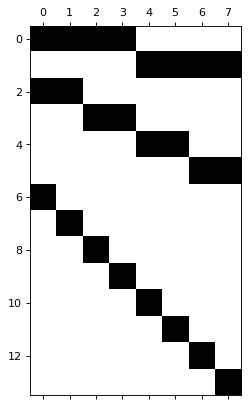

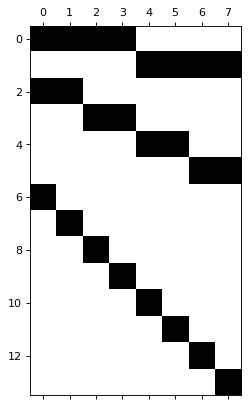

In [18]:
from hierarchicalforecast.utils import HierarchicalPlot

hplot = HierarchicalPlot(S=S_test_df, tags=tags_test, S_id_col="temporal_id")
hplot.plot_summing_matrix()